# Michael Vazquez<br>Econ 570, Assignment 3<br>Forecasting with Random Walk<br>Link to code: https://github.com/Vazquez-Michael-V/570_homework/blob/main/assignment_3/econ_570_assignment_3.ipynb

**Random walk models:**
1. **Random Walk (RW):** $y_t = y_{t-1} + \varepsilon_t$
2. **Random Walk with Drift (RWD):** $y_t = \alpha + y_{t-1} + \varepsilon_t$

These models will be applied to the S&P 500 stock price index for the first part of the assignment, then the same procedures will be applied to the 3 month treasury bill interest rate. Forecast horizons of h = 1 month and h = 2 months will be considered.

**Full timeframee of the dataset:**
Monthly observations from January 2000 to December 2025, 312 observations.

**Training sample timeframe:**
From 2000:01 to 2010:12, 132 observations.

**Holdout timeframe:**
From 2011:01 to 2025:12, 180 forecasts to be made.



# Imports and settings

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Seems to improve quality of the plots.
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11
})


# Functions.

In [147]:
# TODO: Really need to get this into a module.
# Copy and pasted summary statistics from assignment 1. Should create a module for functions that
# will be re-used throught this course.
def summary_statistics(_df: pd.DataFrame, stats_col_name: str, date_col_name: str) -> dict:

    """
    Use this function to find the summary statistics discussed in the slides, "Lecture2_SP2026.pdf".

    Parameters
    ----------
    _df : pd.DataFrame
        Passed DataFrame containing stats_col_name and date_col_name.
    stats_col_name : str
        Column on which to calculate the summary statistics.
    date_col_name : str
        Column on which to find min and max date.

    Returns
    -------
    dict
        Key 'df_summary_stats' contains the DataFrame of summary statistics.
        Key 'min_date' is the minimum of date_col_name.
        Key 'max_date' is the maximum of date_col_name.

    """

    # Added this for when the date column was set as the index.
    _df = _df.reset_index()

    df_summary_stats = pd.DataFrame(
    data={
        'mean': [_df[stats_col_name].mean()],
        'median': [_df[stats_col_name].median()],
        'var': [_df[stats_col_name].var()],
        'std_dev': [_df[stats_col_name].std()],
        'skewness': [_df[stats_col_name].skew()],
        'kurtosis': [_df[stats_col_name].kurtosis()]
        }
    ).T\
    .reset_index(names='statistic')\
    .rename(columns={0: 'value'}, errors='raise')\
    .round(4)

    return {
        'df_summary_stats': df_summary_stats,
        'min_date': _df[date_col_name].min(),
        'max_date': _df[date_col_name].max()
        }


# Notebook variables.

In [148]:
# These dates will be used all throughout the notebook for both the
# S&P and treasury data.
TRAIN_START = '2000-01-01'
TRAIN_END = '2010-12-01'
HOLD_START = '2011-01-01'
HOLD_END = '2025-12-01'

# Load and clean the assignment 3 data.

In [149]:
# header=None because the excel file has a messy layout.
raw = pd.read_excel(
    'Assignment 3 - SP500 and Interest Rate data-1.xlsx',
    sheet_name='S&P 500 and 3-Mo Tr. Bill Data',
    header=None
)
print("Messy file read:")
display(raw.head())


# Drop the first few rows caused by the messy layout.
# Get the required columns.
data = raw.iloc[4:, [1, 2, 4]].copy()
# In the excel file, we see the messy headers contains
# info on the columns. 'rate' here is the '3-mo Treasury Bill Rate Data'.
data.columns = ['date', 'sp500', 'rate']

# Set dtypes.
data['sp500'] = pd.to_numeric(data['sp500'], errors='coerce')
data['rate']  = pd.to_numeric(data['rate'],  errors='coerce')
data['date']  = pd.to_datetime(data['date'],  errors='coerce')

# Set the date as the index, useful for plotting and shifting.
data = data.dropna(subset=['date']).set_index('date').sort_index()

# Ensure dates are as they should be, no extra data in here.
data = data.loc[TRAIN_START:HOLD_END]

# Ensure file was read and df set up properly.
assert data.shape[0] == 312, f'Expected 312 rows, got {data.shape[0]}'
for col in data:
    assert not data[col].hasnans, f"Column {col} has missing values."

print(f'Full sample: {data.index[0].strftime("%Y:%m")} - {data.index[-1].strftime("%Y:%m")}')
print(data.info(show_counts=True, verbose=True))
print(f"data shape: {data.shape}")
data.head()


Messy file read:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,NaN,S&P500 Data,NaN,NaN,3-mo Treasury Bill Rate Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Date,Price (Close),NaN,Rate (ann. %),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2000-01-01 00:00:00,1394.46,NaN,5.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Full sample: 2000:01 - 2025:12
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 312 entries, 2000-01-01 to 2025-12-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sp500   312 non-null    float64
 1   rate    312 non-null    float64
dtypes: float64(2)
memory usage: 7.3 KB
None
data shape: (312, 2)


,sp500,rate
date,,
2000-01-01,1394.46,5.32
2000-02-01,1366.42,5.55
2000-03-01,1498.60,5.69
2000-04-01,1452.40,5.66
2000-05-01,1420.60,5.79


# Plot the S&P 500 and treasury data before starting forecasting.

Before forecasting, let's have a look at the data, both the S&P 500 stock price index and the 3-Month Treasury Bill interest rate over the full timeframe. The shaded orange region marks the holdout period/timeframe.

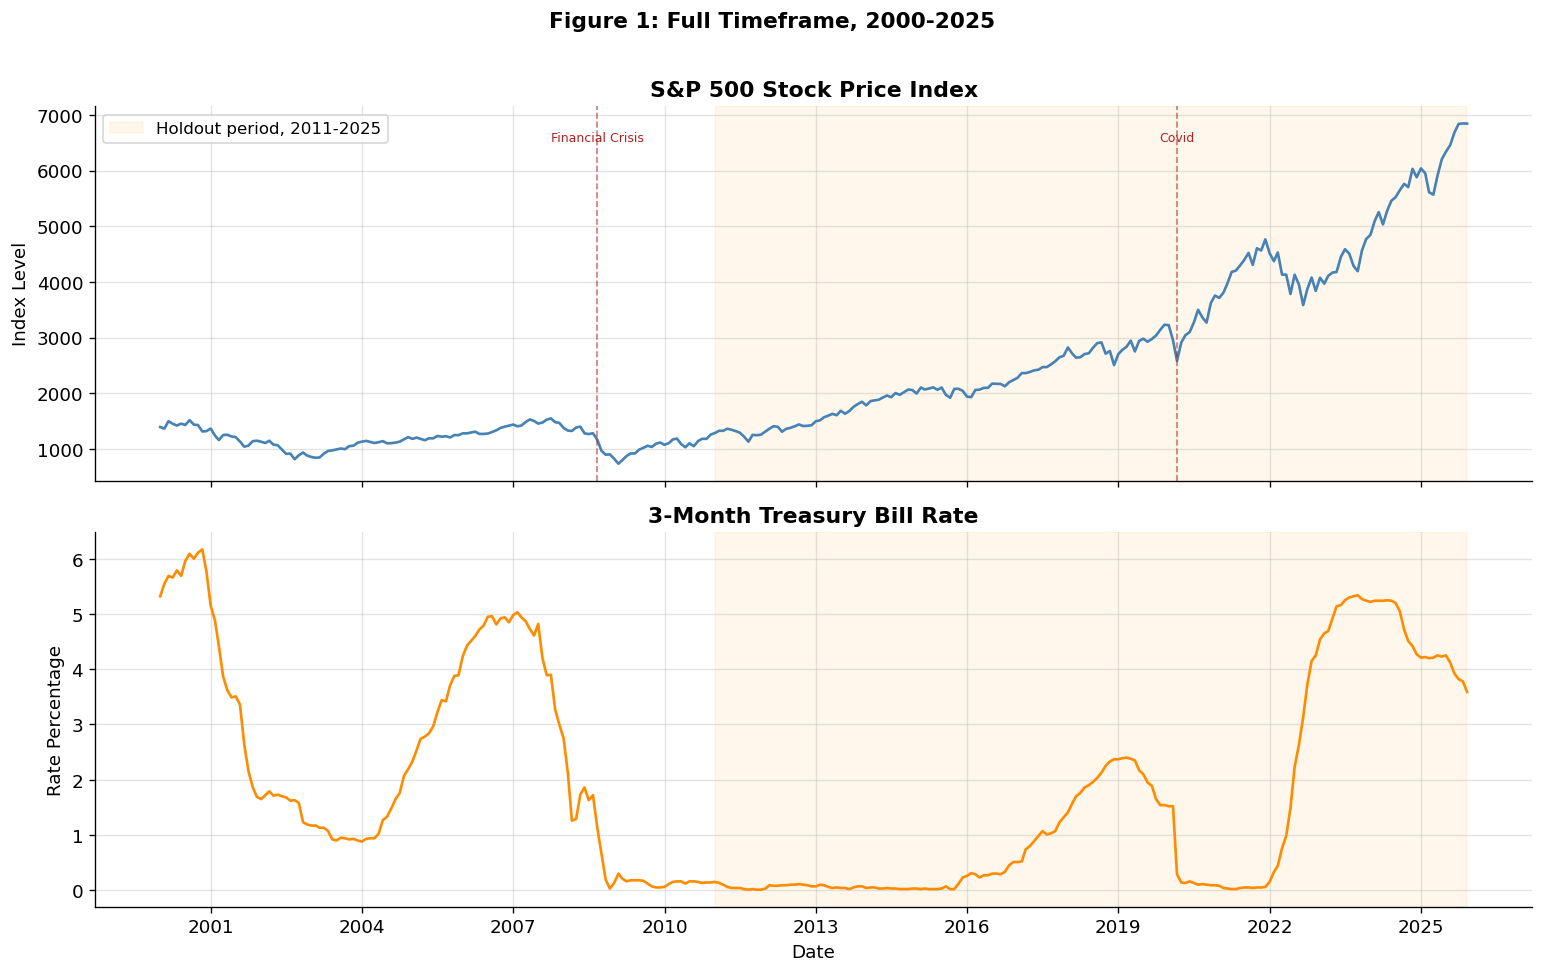

In [150]:
# 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Row 1, Column 1
ax = axes[0]
ax.plot(data.index, data['sp500'], color='steelblue', lw=1.6)
ax.axvspan(
    pd.Timestamp(HOLD_START),
    pd.Timestamp(HOLD_END),
    alpha=0.08,
    color='orange',
    label='Holdout period, 2011-2025'
)
ax.set_title('S&P 500 Stock Price Index', fontweight='bold')
ax.set_ylabel('Index Level')
ax.legend(fontsize=10)

# Annotate the two key economic shocks covered in class, 2008 and 2020.
events = [
    ('2008-09-01', 'Financial Crisis'),
    ('2020-03-01', 'Covid'),
]
for date_str, label in events:
    ts = pd.Timestamp(date_str)
    if ts in data.index:
        ax.axvline(ts, color='firebrick', lw=1.0, ls='--', alpha=0.6)
        ax.text(ts, data['sp500'].max() * 0.98, label,
                fontsize=7.5, color='firebrick', ha='center', va='top')

# 2x1 Plot interest rate
ax2 = axes[1]
ax2.plot(data.index, data['rate'], color='darkorange', lw=1.6)
ax2.axvspan(
    pd.Timestamp(HOLD_START),
    pd.Timestamp(HOLD_END),
    alpha=0.08,
    color='orange')
ax2.set_title('3-Month Treasury Bill Rate', fontweight='bold')
ax2.set_ylabel('Rate Percentage')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
ax2.set_xlabel('Date')

fig.suptitle(
    'Figure 1: Full Timeframe, 2000-2025',
    fontsize=13,
    fontweight='bold',
    y=1.01
)


plt.tight_layout()
plt.show()


**Figure 1 - Discussion**

**S&P 500 Data**
The index has a clear long run upward trend, with significant downturns during the global financial crisis of 2008 and covid in 2020. AS mentioned in a previous assignment, we see here that both the S&P 500 prices and the 3 Month Treasure Bill Rate recovered faster from the economic impacts of covid than the economic impacts of the global financial crisis.

When making our forecasts, we should keep in mind that the 3 Month Treasury Bill Rate is directly impacted by policymakers' decisions, whereas the S&P 500 is more driven by market and business events.

**Example:** a company's stock may increase when appointing a new CEO, which is not likely to be an event caused by government policymakers.


# Summary statistics, covariance, and correlation.

In [151]:
print('Summary statistics, no date filtering:')
stats_500 = summary_statistics(data, 'sp500', 'date')
display(stats_500['df_summary_stats'].round(4))
stats_rate = summary_statistics(data, 'rate', 'date')
display(stats_rate['df_summary_stats'].round(4))

# Covariance and correlation, because we frequently discuss these
# 2 stats in class.
# Both use ddof=1 by default in pandas.
cov_matrix  = data[['sp500', 'rate']].cov(ddof=1)
# Default correlation calculation is Pearson correlation.
# https://pandas.pydata.org/docs/reference/api/pandas.Series.corr.html
corr_matrix = data[['sp500', 'rate']].corr()

cov_val = cov_matrix.loc['sp500', 'rate']
corr_val = corr_matrix.loc['sp500', 'rate']

print(f'\nCovariance of SP500 and Rate, no date filtering: {cov_val:,.4f}')
print(f'Correlation of SP500 and Rate, no date filtering: {corr_val:.4f}')


Summary statistics, no date filtering:


,statistic,value
0,mean,2.276551e+03
1,median,1.528700e+03
2,var,2.154112e+06
3,std_dev,1.467689e+03
4,skewness,1.318900e+00
5,kurtosis,8.436000e-01


,statistic,value
0,mean,1.8896
1,median,1.2300
2,var,3.7378
3,std_dev,1.9334
4,skewness,0.6973
5,kurtosis,-0.9749



Covariance of SP500 and Rate, no date filtering: 834.0447
Correlation of SP500 and Rate, no date filtering: 0.2939


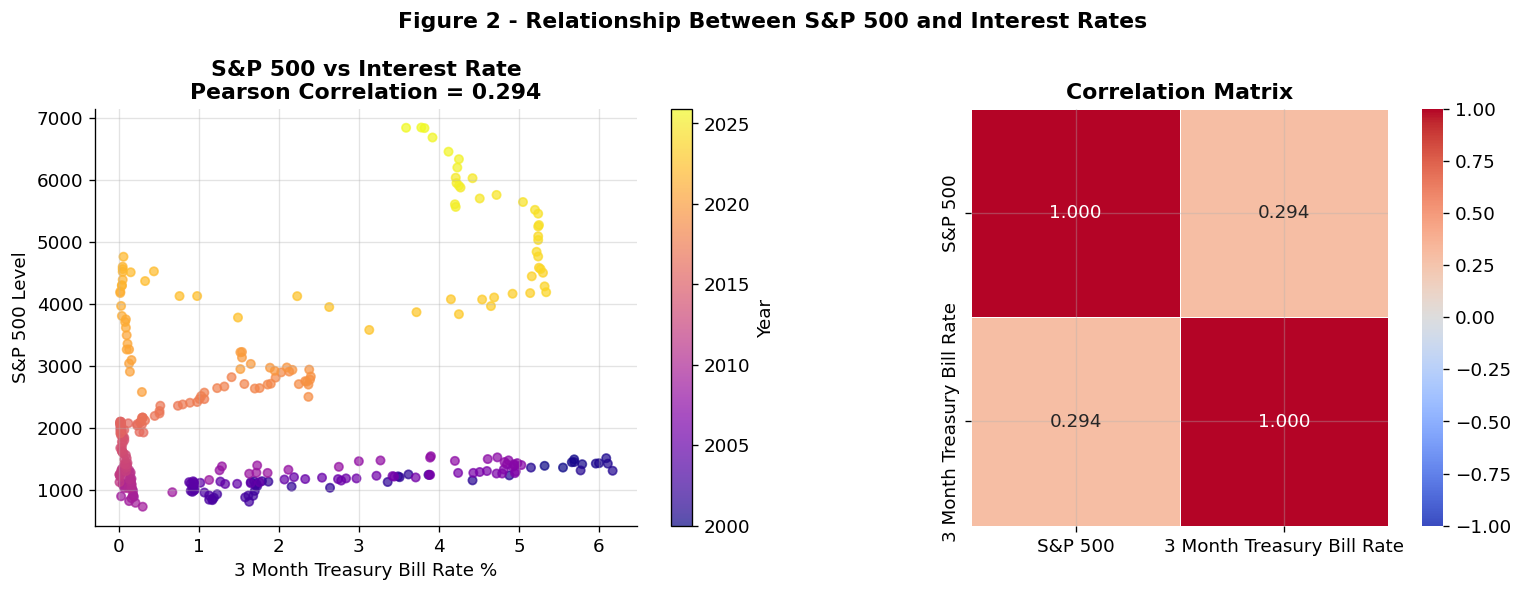

In [152]:
# 1 row, 2 columns.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1x1
# mdates.date2num converts Timestamps to matplotlib's internal float representation.
ax = axes[0]
# Date as index handles the date plotting.
sc = ax.scatter(
    data['rate'],
    data['sp500'],
    c=mdates.date2num(data.index),
    cmap='plasma',
    alpha=0.7,
    s=25
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year')

# Convert year boundaries back to the same float scale to place readable tick labels.
tick_years = [2000, 2005, 2010, 2015, 2020, 2025]
tick_vals  = [mdates.date2num(pd.Timestamp(f'{y}-01-01')) for y in tick_years]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_years)
ax.set_xlabel('3 Month Treasury Bill Rate %')
ax.set_ylabel('S&P 500 Level')
# Specify Pearson correlation to avoid any confusion on what was calculated.
ax.set_title(f'S&P 500 vs Interest Rate\nPearson Correlation = {corr_val:.3f}', fontweight='bold')


# 1x2
ax2 = axes[1]
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=['S&P 500', '3 Month Treasury Bill Rate'],
    yticklabels=['S&P 500', '3 Month Treasury Bill Rate'],
    ax=ax2,
    square=True,
    linewidths=0.5
)
ax2.set_title('Correlation Matrix', fontweight='bold')

fig.suptitle('Figure 2 - Relationship Between S&P 500 and Interest Rates', fontweight='bold')

plt.tight_layout()
plt.show()


**Figure 2 Discussion**

The positive covariance and Pearson correlation between S&P 500 and 3 month treasury bill rate at first appears unusual. When stock prices are decreasing, we expect that the Fed would use monetary policy to reduce the interest rate. However, looking back at Figure 1, and recalling that there were near zero interest rates during the financial crisis, we may suspect that the correlation and covariance are instead caused by economic events across the entire timeframe, rather than a true positive relationship between S&P 500 prices and treasury bill rate.

# Build forecasts of S&P 500 prices.

In the random walk model, the best forecast of tomorrow's value is simply today's value:

$$y_t = y_{t-1} + \varepsilon_t \implies \hat{y}_{t+h|t}^{\text{RW}} = y_t$$

The random walk model has no parameters to estimate, as the $y_{t}$ term encapsulates all economic factors at that given time, ie consumption, savings, etc.

The random walk with drift adds a constant $\alpha$ representing the average change from period to period.

$$y_t = \alpha + y_{t-1} + \varepsilon_t \implies \hat{y}_{t+h|t}^{\text{RWD}} = y_t + h \cdot \hat{\alpha}$$

The drift $\hat{\alpha}$ is estimated as the expanding sample mean of all first differences up to the forecast origin.

### Recursive estimation formula explaination:
The recursive estimation can be performed by using the expanding window and shift functions in pandas, rather than a complicated for loop.
https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.expanding.html
### Note that the index is the date, so shifting is reliable.
https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.shift.html


In [153]:
def recursive_forecast(series, h, hold_start, hold_end):
    """
    Recursive, ie expanding window, horizon h step ahead forecasts
    for both Random Walk and Random Walk with Drift models.
    """
    # Date index covering every target month in the holdout period
    holdout_idx = pd.date_range(hold_start, hold_end, freq='MS')

    #### Build the Random Walk forecast ######
    # shift(h) at position t gives series[t - h], i.e. the level h months
    # before the target. Slicing to holdout_idx obtains only the forecasts
    # we actually need to evaluate.
    # rw for Random Walk.
    rw_fc = series.shift(h).loc[holdout_idx]
    #################################

    #### Build the Random Walk with Drift forecast #######
    # Take the differences as we've done in previous assignments, then use expanindg
    # as in assignment 2, then find the mean over that timeframe.
    expanding_drift = series.diff().expanding().mean()
    # This shift ensures we only use data up until the forecasting time t.
    alpha_at_origin = expanding_drift.shift(h).loc[holdout_idx]
    # Add the drift to the random walk.
    rwd_fc = rw_fc + (h * alpha_at_origin)
    ################################# 

    # Place the actuals and forecasts into a DataFrame for evaluation.
    df = pd.DataFrame({
        'actual': series.loc[holdout_idx],
        'rw_forecast': rw_fc,
        'rwd_forecast': rwd_fc,
    }, index=holdout_idx)

    # forecast error = actual - forecast, same for both models.
    df['rw_error']  = df['actual'] - df['rw_forecast']
    df['rwd_error'] = df['actual'] - df['rwd_forecast']
    
    return df


def compute_loss(fc_df: pd.DataFrame) -> dict:
    """
    Compute MSFE for both random walk and random walk with drift models.
    fc_df is expected to be the DataFrame returned by function recursive_forecast(...)

    Parameters
    ----------
    fc_df : pd.DataFrame
    Output of recursive_forecast().

    Returns
    -------
    dict
    Keys: msfe_rw, msfe_rwd
    """
    errors = fc_df[['rw_error', 'rwd_error']]

    # Square the errors and take the mean, which also handles the 1/P multiplication
    # in the MSFE formula.
    msfe = (errors ** 2).mean()

    return {
        'msfe_rw':  msfe['rw_error'],
        'msfe_rwd': msfe['rwd_error'],
    }


# Run all forecasts over the horizions specified in the assignment.
sp_h1 = recursive_forecast(data['sp500'], h=1, hold_start=HOLD_START, hold_end=HOLD_END)
sp_h2 = recursive_forecast(data['sp500'], h=2, hold_start=HOLD_START, hold_end=HOLD_END)
ir_h1 = recursive_forecast(data['rate'],  h=1, hold_start=HOLD_START, hold_end=HOLD_END)
ir_h2 = recursive_forecast(data['rate'],  h=2, hold_start=HOLD_START, hold_end=HOLD_END)

# Confirm each dataframe covers exactly the 180 holdout months, 2011:01-2025:12.
# Kinda manual but its just 4 elements.
for label, df in [('SP500 h=1', sp_h1),
                  ('SP500 h=2', sp_h2),
                  ('Rate  h=1', ir_h1),
                  ('Rate  h=2', ir_h2)
                ]:
    assert len(df) == 180, f'{label}: expected 180 rows, got {len(df)}'

# Have a look at the forecasts and errors.
print("sp_h1 head:")
display(sp_h1.head())
print("sp_h2 head:")
display(sp_h2.head())
print("ir_h1 head:")
display(ir_h1.head())
print("ir_h2 head:")
display(ir_h2.head())


sp_h1 head:


,actual,rw_forecast,rwd_forecast,rw_error,rwd_error
2011-01-01,1286.1,1257.6,1256.555267,28.5,29.544733
2011-02-01,1327.2,1286.1,1285.279091,41.1,41.920909
2011-03-01,1325.8,1327.2,1326.694286,-1.4,-0.894286
2011-04-01,1363.6,1325.8,1325.287612,37.8,38.312388
2011-05-01,1345.2,1363.6,1363.371407,-18.4,-18.171407


sp_h2 head:


,actual,rw_forecast,rwd_forecast,rw_error,rwd_error
2011-01-01,1286.1,1180.5,1177.208308,105.6,108.891692
2011-02-01,1327.2,1257.6,1255.510534,69.6,71.689466
2011-03-01,1325.8,1286.1,1284.458182,39.7,41.341818
2011-04-01,1363.6,1327.2,1326.188571,36.4,37.411429
2011-05-01,1345.2,1325.8,1324.775224,19.4,20.424776


ir_h1 head:


,actual,rw_forecast,rwd_forecast,rw_error,rwd_error
2011-01-01,0.15,0.14,0.100458,0.01,0.049542
2011-02-01,0.13,0.15,0.110833,-0.02,0.019167
2011-03-01,0.10,0.13,0.090977,-0.03,0.009023
2011-04-01,0.06,0.10,0.061045,-0.04,-0.001045
2011-05-01,0.04,0.06,0.021037,-0.02,0.018963


ir_h2 head:


,actual,rw_forecast,rwd_forecast,rw_error,rwd_error
2011-01-01,0.15,0.14,0.060308,0.01,0.089692
2011-02-01,0.13,0.14,0.060916,-0.01,0.069084
2011-03-01,0.10,0.15,0.071667,-0.05,0.028333
2011-04-01,0.06,0.13,0.051955,-0.07,0.008045
2011-05-01,0.04,0.10,0.022090,-0.06,0.017910


## S&P 500: Forecasts and Forecast Errors

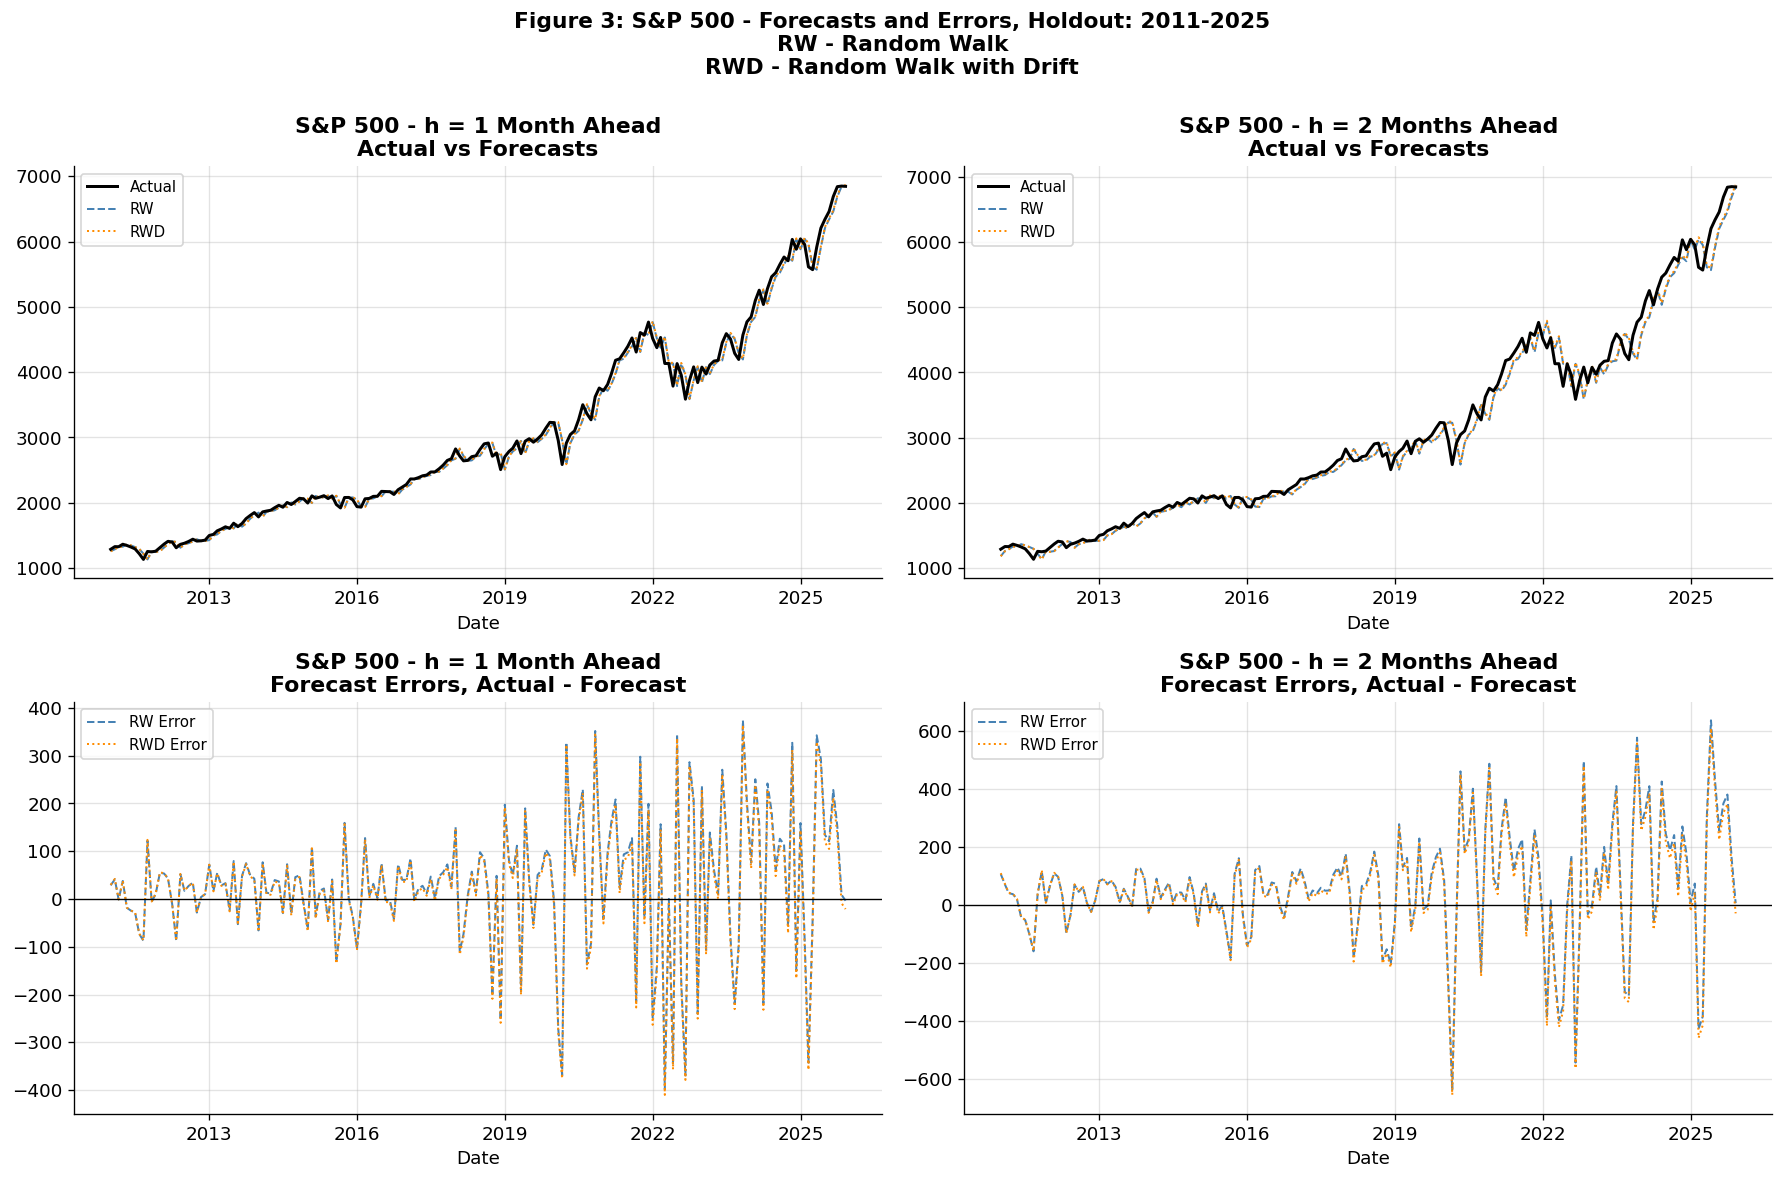

In [154]:
def plot_forecasts_and_errors(fc_h1, fc_h2, series_label, fig_num,
                              color_rw='steelblue', color_rwd='darkorange'):
    """
    Function for plotting 2x2 grid of forecasts and errors, with actuals vs forecasts on the top row
    and forecast errrors on the bottom row.
    """

    # 2x2
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for col, (fc, title) in enumerate(zip([fc_h1, fc_h2],
                                           ['h = 1 Month Ahead', 'h = 2 Months Ahead'])):
        ax = axes[0, col]
        ax.plot(fc.index, fc['actual'],       color='black',   lw=1.8, label='Actual', zorder=3)
        ax.plot(fc.index, fc['rw_forecast'],  color=color_rw,  lw=1.2, ls='--', label='RW')
        ax.plot(fc.index, fc['rwd_forecast'], color=color_rwd, lw=1.2, ls=':',  label='RWD')
        ax.set_title(f'{series_label} - {title}\nActual vs Forecasts', fontweight='bold')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.set_xlabel('Date')

        ax2 = axes[1, col]
        ax2.plot(fc.index, fc['rw_error'],  color=color_rw,  lw=1.2, ls='--', label='RW Error')
        ax2.plot(fc.index, fc['rwd_error'], color=color_rwd, lw=1.2, ls=':',  label='RWD Error')
        ax2.axhline(0, color='black', lw=0.8)
        ax2.set_title(f'{series_label} - {title}\nForecast Errors, Actual - Forecast', fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax2.xaxis.set_major_locator(mdates.YearLocator(3))
        ax2.set_xlabel('Date')

    fig.suptitle(
        f'Figure {fig_num}: {series_label} - Forecasts and Errors, Holdout: 2011-2025\nRW - Random Walk\nRWD - Random Walk with Drift\n',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


plot_forecasts_and_errors(sp_h1, sp_h2, 'S&P 500', fig_num=3)

**Figure 3 Discussion - S&P 500 Forecasts and Errors**
In the top row of Figure 3, we see that both models provide good forecasts compared to the actual. In the bottom row, the error terms do not show any trend, and do not shoot off to any relatively large values. The h = 1 errors are roughly within -400 to +400, and the h = 2 errrors are roughly within -600 to +600. Visually, these errors do not raise any concerns about model assumption violations.


## S&P 500 - Comparing MSFEs

In [155]:
sp_loss_h1 = compute_loss(sp_h1)
sp_loss_h2 = compute_loss(sp_h2)

print('S&P 500 MSFE')
for label, loss in [('h = 1', sp_loss_h1), ('h = 2', sp_loss_h2)]:
    # Let's say the winner, winning model, has the lowest error ie loss.
    winner = 'RW' if loss['msfe_rw'] < loss['msfe_rwd'] else 'RWD'
    print(f"{label}:  RW  MSFE = {loss['msfe_rw']}")
    print(f"{label}:  RWD MSFE = {loss['msfe_rwd']}")
    print(f"Best model: {winner}\n")


S&P 500 MSFE
h = 1:  RW  MSFE = 20025.041836666667
h = 1:  RWD MSFE = 19571.08705108947
Best model: RWD

h = 2:  RW  MSFE = 38551.484415
h = 2:  RWD MSFE = 36712.017893751516
Best model: RWD



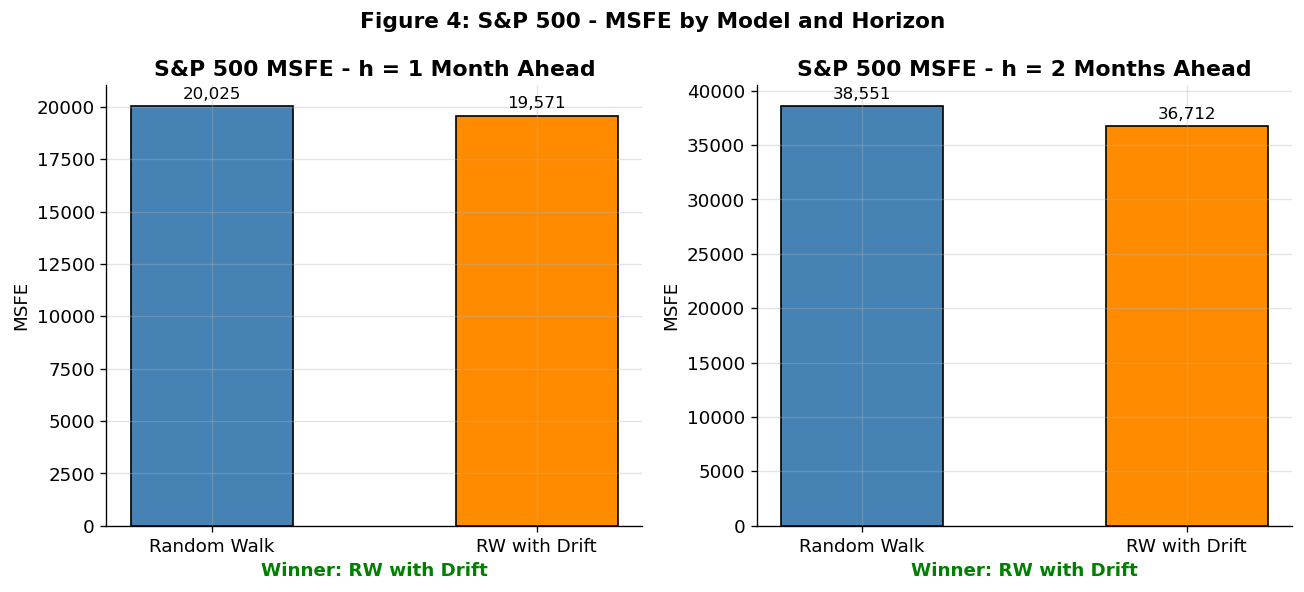

In [156]:
def plot_msfe_bars(loss_h1, loss_h2, series_label, fig_num,
                   color_rw='steelblue', color_rwd='darkorange', large_values=True):
    """
    Bar chart comparing MSFE for RW vs RWD at h=1 and h=2.
    """

    # Need large values to display nicely.
    fmt = ',.0f' if large_values else '.4f'

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (h, loss) in zip(axes, [(1, loss_h1), (2, loss_h2)]):
        models = ['Random Walk', 'RW with Drift']
        vals   = [loss['msfe_rw'], loss['msfe_rwd']]
        bars   = ax.bar(models, vals, color=[color_rw, color_rwd],
                        edgecolor='black', width=0.5)
        ax.bar_label(bars, labels=[f'{v:{fmt}}' for v in vals],
                     padding=3, fontsize=10)
        ax.set_title(f'{series_label} MSFE - h = {h} Month{"s" if h > 1 else ""} Ahead',
                     fontweight='bold')
        ax.set_ylabel('MSFE')
        winner = models[0] if loss['msfe_rw'] < loss['msfe_rwd'] else models[1]
        ax.set_xlabel(f'Winner: {winner}', color='green', fontweight='bold')
    fig.suptitle(f'Figure {fig_num}: {series_label} - MSFE by Model and Horizon',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig{fig_num}_msfe.png', bbox_inches='tight')
    plt.show()


plot_msfe_bars(sp_loss_h1, sp_loss_h2, 'S&P 500', fig_num=4)


# Interest Rate Forecasting

Using the same functions as with the S&P 500 data, now plug in the treasury bill data and perform the same analysis.

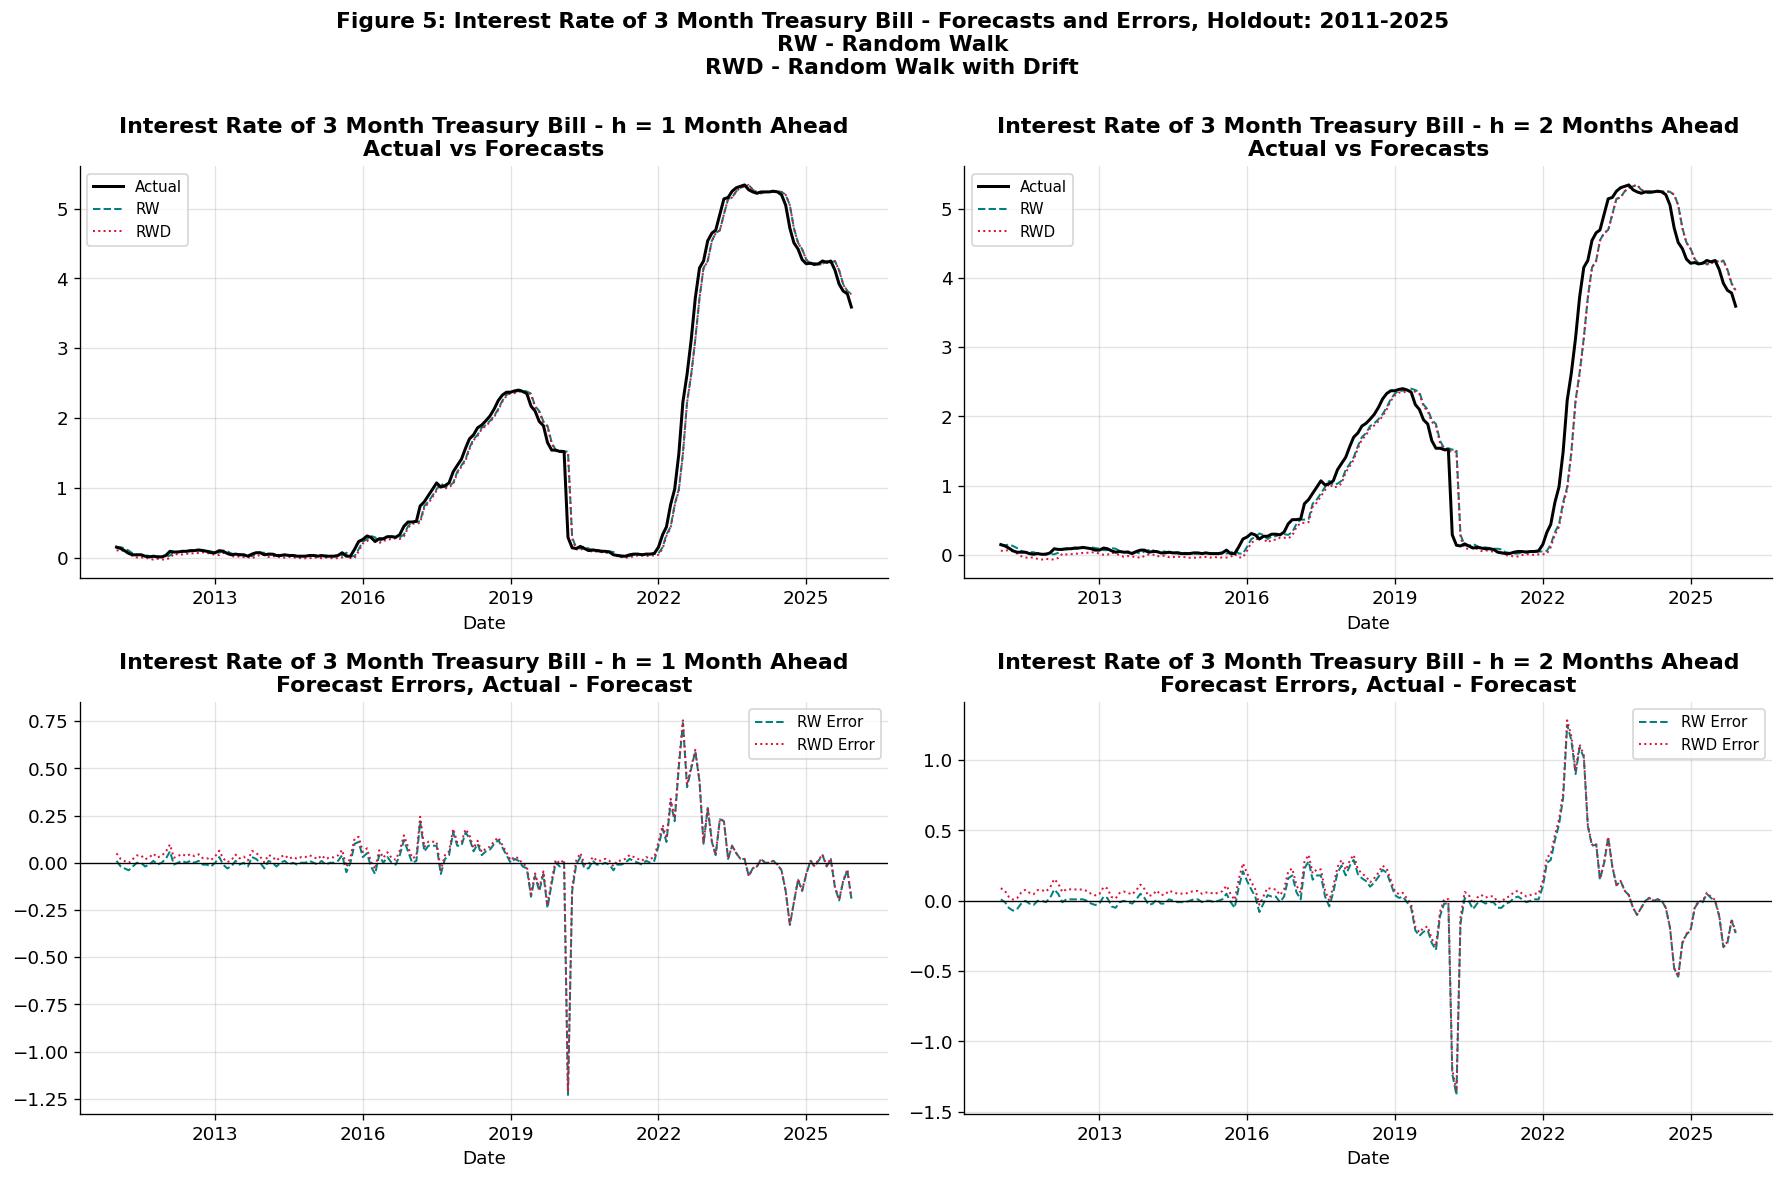

In [157]:
plot_forecasts_and_errors(
    ir_h1,
    ir_h2,
    'Interest Rate of 3 Month Treasury Bill',
    fig_num=5,
    color_rw='teal',
    color_rwd='crimson'
)

In [158]:
# Compute losses for both interest rate horizons
ir_loss_h1 = compute_loss(ir_h1)
ir_loss_h2 = compute_loss(ir_h2)

print('Interest Rate - MSFE (Mean Square Forecast Error)')
# Rate values are small (0-6%), so MSFEs will be much smaller in absolute
# terms than for the SP500 — compare within series, not across series
for label, loss in [('h = 1', ir_loss_h1), ('h = 2', ir_loss_h2)]:
    winner = 'RW' if loss['msfe_rw'] < loss['msfe_rwd'] else 'RWD'
    print(f"{label}: RW  MSFE = {loss['msfe_rw']:.5f}")
    print(f"{label}: RWD MSFE = {loss['msfe_rwd']:.5f}")
    print(f"Best model: {winner}")
    print()


Interest Rate - MSFE (Mean Square Forecast Error)
h = 1: RW  MSFE = 0.02484
h = 1: RWD MSFE = 0.02603
Best model: RW

h = 2: RW  MSFE = 0.07749
h = 2: RWD MSFE = 0.08251
Best model: RW



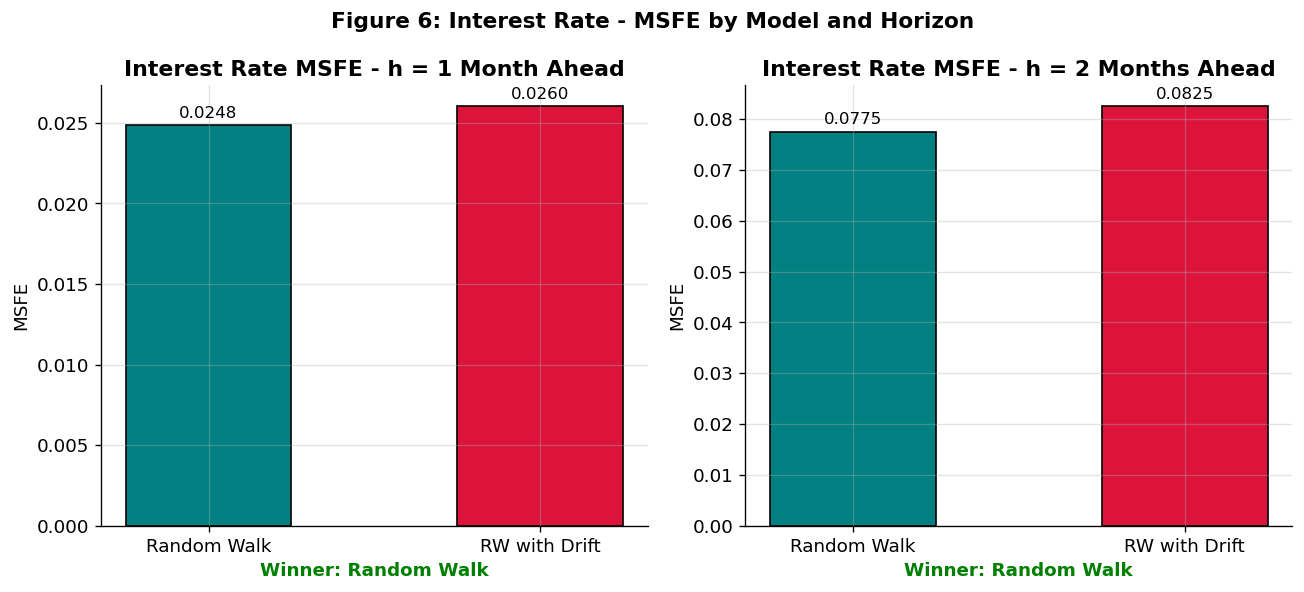

In [159]:
plot_msfe_bars(ir_loss_h1, ir_loss_h2, 'Interest Rate', fig_num=6,
               color_rw='teal', color_rwd='crimson', large_values=False)


# Model summaries, S&P 500 and 3 Month Treasury Bill Rate

In [160]:
# Compile all four loss dicts into a DataFrame.
loss_index = [
    ('S&P 500', 'h=1', sp_loss_h1),
    ('S&P 500', 'h=2', sp_loss_h2),
    ('3 Month Treasury Bill Rate', 'h=1', ir_loss_h1),
    ('3 Month Treasury Bill Rate','h=2', ir_loss_h2),
]

summary = pd.DataFrame([
    {
        'Series': series,
        'Horizon': h,
        'MSFE (RW)': loss['msfe_rw'],
        'MSFE (RWD)': loss['msfe_rwd'],
        'Best Model': 'RW' if loss['msfe_rw'] < loss['msfe_rwd'] else 'RWD',
    }
    for series, h, loss in loss_index
])

print("Overall summary results:")
display(summary)


Overall summary results:


,Series,Horizon,MSFE (RW),MSFE (RWD),Best Model
0,S&P 500,h=1,20025.041837,19571.087051,RWD
1,S&P 500,h=2,38551.484415,36712.017894,RWD
2,3 Month Treasury Bill Rate,h=1,0.024838,0.026026,RW
3,3 Month Treasury Bill Rate,h=2,0.077486,0.082509,RW


# Comparing S&P 500 and Interest Rate Results

As expected from the plots in Figure 1 and from previous assignments, the historical averages fail to account for economic shocks such as 2008 financial crisis and 2020 covid, but do perform quite well in normal, ie not a shocked period, economic conditions. The random walk with drift outperforms the random walk with the S&P 500 data, whereas the random walk model is preferred for the 3 month treasury bill data.

